# Giảm chiều MNIST – Phiên bản Chi-Square (song song với PCA)

**Đề tài:**
- Thực hiện **chọn đặc trưng Chi-Square** (SelectKBest + chi2) cho MNIST.
- Đánh giá **baseline** (dữ liệu gốc) và **sau giảm chiều**.
- So sánh: **tiêu thụ bộ nhớ**, **thời gian xử lý** (fit + predict), **hao hụt độ chính xác**.

## 1. Import và tải dữ liệu

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from lib import (
    MNISTDataLoader,
    MNISTClassifier,
    ChiSquareReducer,
    measure_array_memory_mb,
    run_and_measure_seconds,
    plot_comparison_reduction,
    print_comparison_table,
    plot_confusion_matrix,
    print_classification_report,
)
import matplotlib.pyplot as plt

In [2]:
loader = MNISTDataLoader(normalize=True, flatten=True)
X_train, y_train, X_test, y_test = loader.load()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Số chiều gốc: {X_train.shape[1]}")

X_train: (60000, 784), X_test: (10000, 784)
Số chiều gốc: 784


## 2. Baseline – Đánh giá trên dữ liệu gốc (784 chiều)

In [3]:
baseline_memory_mb = measure_array_memory_mb(X_train)
print(f"Bộ nhớ X_train (baseline): {baseline_memory_mb:.4f} MB")

Bộ nhớ X_train (baseline): 358.8867 MB


In [4]:
clf_baseline = MNISTClassifier(model_type="logistic", random_state=42)

_, time_fit_baseline = run_and_measure_seconds(lambda: clf_baseline.fit(X_train, y_train))
_, time_predict_baseline = run_and_measure_seconds(lambda: clf_baseline.predict(X_test))

acc_baseline = clf_baseline.score(X_test, y_test)

baseline_metrics = {
    "memory_mb": baseline_memory_mb,
    "time_fit_s": time_fit_baseline,
    "time_predict_s": time_predict_baseline,
    "accuracy": acc_baseline,
}
print(f"Baseline - Fit: {time_fit_baseline:.4f} s, Predict: {time_predict_baseline:.4f} s, Accuracy: {acc_baseline:.4f}")

Baseline - Fit: 19.5181 s, Predict: 0.0220 s, Accuracy: 0.9257


## 3. Giảm chiều bằng Chi-Square (SelectKBest)

Giống PCA, có hai cách:
- **Số đặc trưng (int):** giữ top-k đặc trưng theo điểm Chi-Square.
- **Độ chính xác tối thiểu (float 0–1):** tìm số đặc trưng k nhỏ nhất sao cho classifier đạt ít nhất accuracy đó (có thể truyền `X_val, y_val` để tìm k theo validation).

In [5]:
# Chế độ 1: Số đặc trưng cố định (int)
n_components = 154
# Chế độ 2: Độ chính xác tối thiểu (float) – bỏ comment 2 dòng dưới và comment 2 dòng trên
# n_components = 0.92  # tìm k nhỏ nhất đạt >= 92% accuracy (train hoặc val)
# reducer = ChiSquareReducer(n_components=n_components, random_state=42)
# X_train_reduced = reducer.fit_transform(X_train, y_train, X_val=X_test, y_val=y_test)

reducer = ChiSquareReducer(n_components=n_components, random_state=42)
X_train_reduced = reducer.fit_transform(X_train, y_train)
X_test_reduced = reducer.transform(X_test)

print(f"Số chiều sau giảm: {reducer.n_components_}")
if reducer.min_accuracy_reached() is not None:
    print(f"Độ chính xác đạt được (chế độ float): {reducer.min_accuracy_reached():.4f}")

Số chiều sau giảm: 154


In [6]:
reduced_memory_mb = measure_array_memory_mb(X_train_reduced)
print(f"Bộ nhớ X_train (sau giảm chiều): {reduced_memory_mb:.4f} MB")

Bộ nhớ X_train (sau giảm chiều): 70.4956 MB


## 4. Đánh giá trên dữ liệu sau giảm chiều

In [7]:
clf_reduced = MNISTClassifier(model_type="logistic", random_state=42)

_, time_fit_reduced = run_and_measure_seconds(lambda: clf_reduced.fit(X_train_reduced, y_train))
_, time_predict_reduced = run_and_measure_seconds(lambda: clf_reduced.predict(X_test_reduced))

acc_reduced = clf_reduced.score(X_test_reduced, y_test)

reduced_metrics = {
    "memory_mb": reduced_memory_mb,
    "time_fit_s": time_fit_reduced,
    "time_predict_s": time_predict_reduced,
    "accuracy": acc_reduced,
}
print(f"Sau giảm chiều - Fit: {time_fit_reduced:.4f} s, Predict: {time_predict_reduced:.4f} s, Accuracy: {acc_reduced:.4f}")

Sau giảm chiều - Fit: 3.9723 s, Predict: 0.0045 s, Accuracy: 0.8816


## 5. So sánh: Bộ nhớ, Thời gian, Độ chính xác

In [8]:
print_comparison_table(baseline_metrics, reduced_metrics, reduced_name="Sau giảm chiều (Chi-Square)")

BẢNG SO SÁNH: BASELINE vs SAU GIẢM CHIỀU
Chỉ số                        Baseline Sau giảm chiều (Chi-Square)   Chênh lệch
------------------------------------------------------------
Bộ nhớ (MB)                   358.8867      70.4956      +80.36%
Thời gian fit (s)              19.5181       3.9723
Thời gian predict (s)           0.0220       0.0045
Độ chính xác (%)                 92.57        88.16       +4.76% (hao hụt)


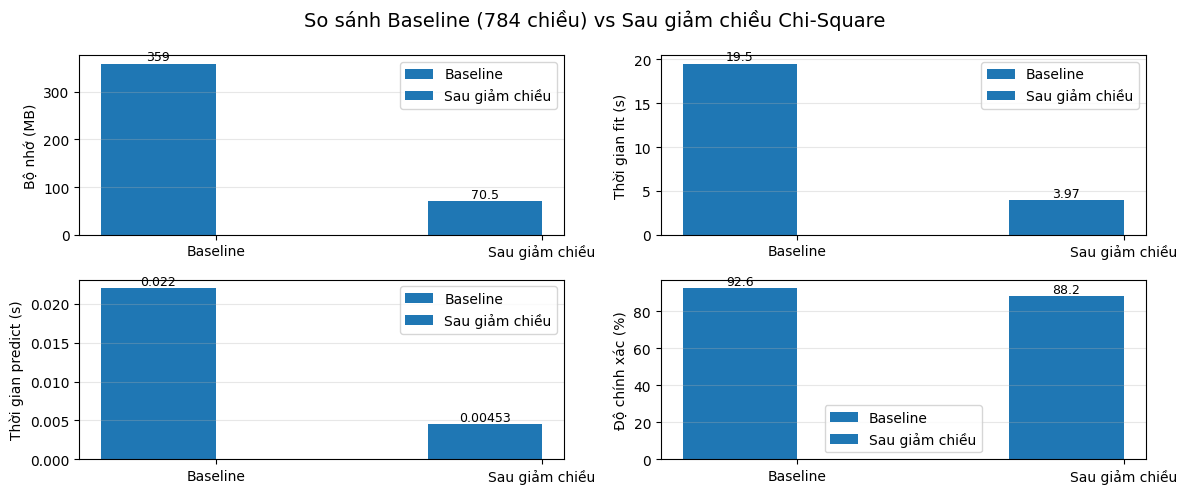

In [9]:
fig = plot_comparison_reduction(
    baseline_metrics,
    reduced_metrics,
    title="So sánh Baseline (784 chiều) vs Sau giảm chiều Chi-Square",
)
plt.show()

## 6. Báo cáo phân lớp và Confusion Matrix (sau giảm chiều)

In [10]:
y_pred_reduced = clf_reduced.predict(X_test_reduced)
class_names = loader.get_class_names()

print("Báo cáo phân lớp (mô hình trên dữ liệu sau giảm chiều):")
print_classification_report(y_test, y_pred_reduced, class_names=class_names)

Báo cáo phân lớp (mô hình trên dữ liệu sau giảm chiều):
              precision    recall  f1-score   support

           0     0.9364    0.9622    0.9492       980
           1     0.9558    0.9718    0.9637      1135
           2     0.9015    0.8692    0.8851      1032
           3     0.8849    0.8752    0.8800      1010
           4     0.8364    0.8279    0.8321       982
           5     0.8425    0.8274    0.8348       892
           6     0.8904    0.8987    0.8945       958
           7     0.9028    0.9037    0.9033      1028
           8     0.8432    0.8450    0.8441       974
           9     0.8049    0.8176    0.8112      1009

    accuracy                         0.8816     10000
   macro avg     0.8799    0.8799    0.8798     10000
weighted avg     0.8814    0.8816    0.8814     10000



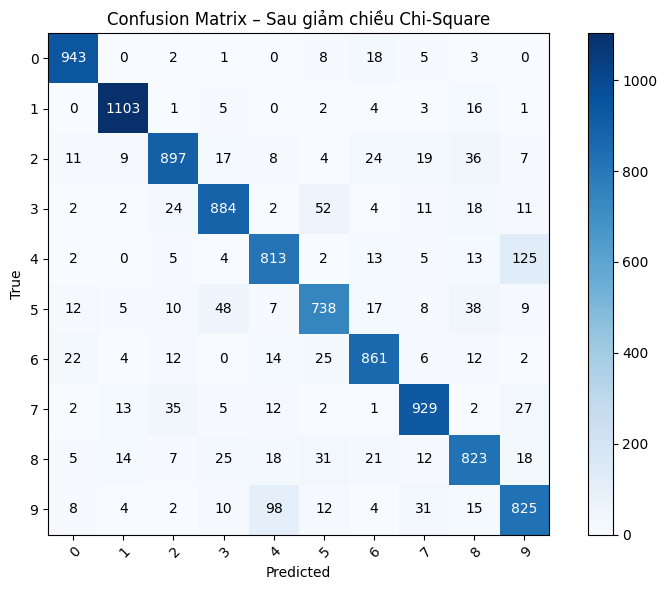

In [11]:
fig = plot_confusion_matrix(y_test, y_pred_reduced, class_names=class_names, title="Confusion Matrix – Sau giảm chiều Chi-Square")
plt.show()

## 7. (Tùy chọn) Thử nhiều mức: số đặc trưng (k) và độ chính xác tối thiểu

In [ ]:
results = []
for k in [300, 154, 100, 50, 30]:
    r = ChiSquareReducer(n_components=k, random_state=42)
    X_tr = r.fit_transform(X_train, y_train)
    X_te = r.transform(X_test)
    mem = measure_array_memory_mb(X_tr)
    clf = MNISTClassifier(model_type="logistic", random_state=42)
    clf.fit(X_tr, y_train)
    acc = clf.score(X_te, y_test)
    results.append({"k": k, "dims": r.n_components_, "memory_mb": mem, "accuracy": acc})

print(f"{'số đặc trưng':<20} | {'Số chiều':<10} | {'Bộ nhớ (MB)':<15} | {'Accuracy':<10}")
for row in results:
    print(f"{row['k']:<20} | {row['dims']:<10} | {row['memory_mb']:08.4f}        | {row['accuracy']:.4f}")

k (số đặc trưng)     | Số chiều   | Bộ nhớ (MB)     | Accuracy  
300                  | 300        | 137.3291        | 0.9172
154                  | 154        | 070.4956        | 0.8816
100                  | 100        | 045.7764        | 0.8252
50                   | 50         | 022.8882        | 0.6639
30                   | 30         | 013.7329        | 0.5947


### Thử theo độ chính xác tối thiểu (float)

Tìm số đặc trưng k nhỏ nhất sao cho accuracy (trên validation) >= ngưỡng. Truyền `X_val, y_val` vào `fit()` để tìm k theo validation.

In [ ]:
results_acc = []
for min_acc in [0.90, 0.92, 0.95]:
    r = ChiSquareReducer(n_components=min_acc, random_state=42)
    X_tr = r.fit_transform(X_train, y_train, X_val=X_test, y_val=y_test)
    X_te = r.transform(X_test)
    mem = measure_array_memory_mb(X_tr)
    clf = MNISTClassifier(model_type="logistic", random_state=42)
    clf.fit(X_tr, y_train)
    acc = clf.score(X_te, y_test)
    results_acc.append({"min_accuracy": min_acc, "dims": r.n_components_, "memory_mb": mem, "accuracy": acc})

print("Chế độ: Độ chính xác tối thiểu (float) – tìm k nhỏ nhất đạt >= min_accuracy (validation = test)")
print(f"{'min_acc':<10} | {'Số chiều':<10} | {'Bộ nhớ (MB)':<12} | {'Accuracy':<10}")
for row in results_acc:
    print(f"{row['min_accuracy']:<10} | {row['dims']:<10} | {row['memory_mb']:.4f}       | {row['accuracy']:.4f}")